# **📌 Extracción**

1️⃣ Cargar y normalizar correctamente

In [1]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()

df = pd.DataFrame(data)

customer_df = pd.json_normalize(df["customer"])
phone_df = pd.json_normalize(df["phone"])
internet_df = pd.json_normalize(df["internet"])
account_df = pd.json_normalize(df["account"])

df_final = pd.concat(
    [df[["customerID", "Churn"]],
     customer_df,
     phone_df,
     internet_df,
     account_df],
    axis=1
)

df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# **🔧 Transformación**

2️⃣ Limpiar espacios en texto

In [2]:
for col in df_final.select_dtypes(include="object").columns:
    df_final[col] = df_final[col].str.strip()

3️⃣ Eliminar Churn vacío (ANTES de mapear)

In [3]:
df_final = df_final[df_final["Churn"] != ""]

In [4]:
df_final["Churn"].unique()

array(['No', 'Yes'], dtype=object)

4️⃣ Convertir Churn a binaria

In [5]:
df_final["Churn"] = (
    df_final["Churn"]
    .str.strip()
    .str.upper()
    .map({"YES": 1, "NO": 0})
)

In [6]:
df_final["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [7]:
df_final["Churn"].value_counts(dropna=False)

,count
Churn,
0,5174
1,1869


In [8]:
df_final["Churn"].unique()

array([0, 1])

In [9]:
df_final["Churn"].dtype

dtype('int64')

In [10]:
df_final.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [11]:
df_final.groupby("Churn")["Charges.Monthly"].mean()

,Charges.Monthly
Churn,
0,61.265124
1,74.441332


5️⃣ Verificacion de datos

In [12]:
df_final["Charges.Monthly"].dtype

dtype('float64')

In [13]:
df_final.shape

(7043, 21)

In [14]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   int64  
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

In [15]:
df_final.isnull().sum().sort_values(ascending=False)

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [16]:
for col in df_final.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df_final[col].unique())


customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

gender
['Female' 'Male']

Partner
['Yes' 'No']

Dependents
['Yes' 'No']

PhoneService
['Yes' 'No']

MultipleLines
['No' 'Yes' 'No phone service']

InternetService
['DSL' 'Fiber optic' 'No']

OnlineSecurity
['No' 'Yes' 'No internet service']

OnlineBackup
['Yes' 'No' 'No internet service']

DeviceProtection
['No' 'Yes' 'No internet service']

TechSupport
['Yes' 'No' 'No internet service']

StreamingTV
['Yes' 'No' 'No internet service']

StreamingMovies
['No' 'Yes' 'No internet service']

Contract
['One year' 'Month-to-month' 'Two year']

PaperlessBilling
['Yes' 'No']

PaymentMethod
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']

Charges.Total
['593.3' '542.4' '280.85' ... '742.9' '4627.65' '3707.6']


In [17]:
df_final.describe()

,Churn,SeniorCitizen,tenure,Charges.Monthly
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,32.371149,64.761692
std,0.441561,0.368612,24.559481,30.090047
min,0.000000,0.000000,0.000000,18.250000
25%,0.000000,0.000000,9.000000,35.500000
50%,0.000000,0.000000,29.000000,70.350000
75%,1.000000,0.000000,55.000000,89.850000
max,1.000000,1.000000,72.000000,118.750000


In [18]:
df_final["Charges.Total"] = (
    df_final["Charges.Total"]
    .replace(" ", pd.NA)
)

df_final["Charges.Total"] = pd.to_numeric(
    df_final["Charges.Total"],
    errors="coerce"
)

In [19]:
df_final["Charges.Total"].dtype

dtype('float64')

In [20]:
df_final = df_final[df_final["Charges.Total"].notna()]

In [21]:
df_final[
    (df_final["tenure"] == 0) &
    (df_final["Charges.Total"] > 0)
]

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total


Crear la columna Cuentas_Diarias

In [22]:
df_final["Cuentas_Diarias"] = df_final["Charges.Monthly"] / 30

In [23]:
df_final[["Charges.Monthly", "Cuentas_Diarias"]].head()

,Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [24]:
(df_final["Cuentas_Diarias"] * 30).round(2).head()

,Cuentas_Diarias
0,65.6
1,59.9
2,73.9
3,98.0
4,83.9


In [25]:
df_final["Cuentas_Diarias"] = (df_final["Charges.Monthly"] / 30).round(2)

In [26]:
df_final["Cuentas_Diarias"].describe()

,Cuentas_Diarias
count,7032.000000
mean,2.159891
std,1.002955
min,0.610000
25%,1.187500
50%,2.340000
75%,2.992500
max,3.960000


# **📊 Carga y análisis**

Análisis Descriptivo

In [27]:
df_final.describe()

,Churn,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,32.421786,64.798208,2283.300441,2.159891
std,0.441782,0.368844,24.545260,30.085974,2266.771362,1.002955
min,0.000000,0.000000,1.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,9.000000,35.587500,401.450000,1.187500
50%,0.000000,0.000000,29.000000,70.350000,1397.475000,2.340000
75%,1.000000,0.000000,55.000000,89.862500,3794.737500,2.992500
max,1.000000,1.000000,72.000000,118.750000,8684.800000,3.960000


Distribución de evasión

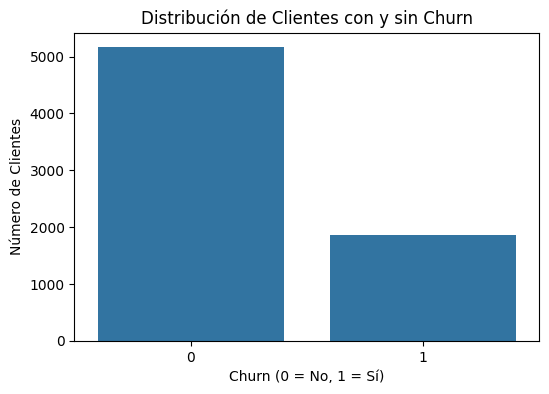

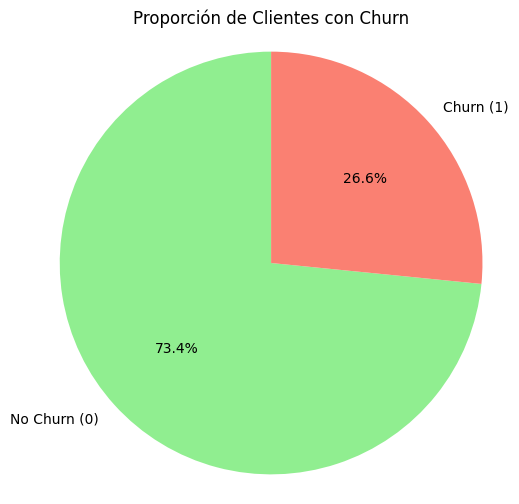

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de barras para la distribución de Churn
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df_final)
plt.title('Distribución de Clientes con y sin Churn')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Número de Clientes')
plt.show()

# Gráfico de pastel para la proporción de Churn
churn_counts = df_final['Churn'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(churn_counts, labels=['No Churn (0)', 'Churn (1)'], autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'salmon'])
plt.title('Proporción de Clientes con Churn')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

Recuento de evasión por variables categóricas

Tasa general de churn

In [29]:
churn_rate = df_final["Churn"].mean()
churn_rate
churn_rate * 100

np.float64(26.578498293515356)

Churn por género

In [30]:
df_final.groupby("gender")["Churn"].mean().sort_values(ascending=False) * 100

,Churn
gender,
Female,26.959518
Male,26.204565


Churn por tipo de contrato

In [31]:
df_final.groupby("Contract")["Churn"].mean().sort_values(ascending=False) * 100

,Churn
Contract,
Month-to-month,42.709677
One year,11.277174
Two year,2.848665


Churn por método de pago

In [32]:
df_final.groupby("PaymentMethod")["Churn"].mean().sort_values(ascending=False) * 100

,Churn
PaymentMethod,
Electronic check,45.285412
Mailed check,19.201995
Bank transfer (automatic),16.731518
Credit card (automatic),15.253123


Churn por InternetService

In [33]:
df_final.groupby("InternetService")["Churn"].mean().sort_values(ascending=False) * 100

,Churn
InternetService,
Fiber optic,41.892765
DSL,18.998344
No,7.434211


Churn por PaperlessBilling

In [34]:
df_final.groupby("PaperlessBilling")["Churn"].mean().sort_values(ascending=False) * 100

,Churn
PaperlessBilling,
Yes,33.589251
No,16.375698


In [35]:
df_final["Contract"].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1685
One year,1472


In [36]:
perfiles_riesgo = df_final.groupby(
    ['Contract', 'InternetService', 'TechSupport']
).agg(
    Total_Clientes=('Churn', 'count'),
    Clientes_Que_Cancelan=('Churn', 'sum'),
    Tasa_Churn_Pct=('Churn', lambda x: round(x.mean() * 100, 2)),
    Ingreso_Promedio=('Charges.Monthly', 'mean')
).reset_index()

# Calcular pérdida mensual estimada real
perfiles_riesgo['Perdida_Mensual_Estimada'] = (
    perfiles_riesgo['Clientes_Que_Cancelan'] *
    perfiles_riesgo['Ingreso_Promedio']
)

# Filtrar grupos pequeños
perfiles_riesgo = perfiles_riesgo[
    perfiles_riesgo['Total_Clientes'] > 50
]

perfiles_riesgo.sort_values(
    'Perdida_Mensual_Estimada',
    ascending=False
).head(10)

,Contract,InternetService,TechSupport,Total_Clientes,Clientes_Que_Cancelan,Tasa_Churn_Pct,Ingreso_Promedio,Perdida_Mensual_Estimada
2,Month-to-month,Fiber optic,No,1796,1033,57.52,85.493680,88314.971854
0,Month-to-month,DSL,No,884,317,35.86,47.497285,15056.639367
3,Month-to-month,Fiber optic,Yes,332,129,38.86,95.284488,12291.698946
7,One year,Fiber optic,No,313,58,18.53,96.379233,5589.995527
8,One year,Fiber optic,Yes,226,46,20.35,102.103761,4696.773009
1,Month-to-month,DSL,Yes,339,77,22.71,57.318142,4413.496903
13,Two year,Fiber optic,Yes,308,21,6.82,106.844481,2243.734091
4,Month-to-month,No,No internet service,524,99,18.89,20.409542,2020.544656
6,One year,DSL,Yes,326,29,8.90,64.330061,1865.571779
5,One year,DSL,No,244,24,9.84,57.477664,1379.463934


Conteo de evasión por variables numéricas

In [37]:
df_final.groupby("Churn")[["tenure", "Charges.Monthly", "Charges.Total"]].agg(
    ["mean", "median"]
)

tenure        Charges.Monthly        Charges.Total         
            mean median            mean median          mean   median
Churn                                                                
0      37.650010   38.0       61.307408  64.45   2555.344141  1683.60
1      17.979133   10.0       74.441332  79.65   1531.796094   703.55

In [38]:
comparacion_numericas = df_final.groupby("Churn").agg(
    Clientes=("Churn", "count"),
    Promedio_Tenure=("tenure", "mean"),
    Mediana_Tenure=("tenure", "median"),
    Promedio_Mensual=("Charges.Monthly", "mean"),
    Promedio_Total=("Charges.Total", "mean")
)

comparacion_numericas

,Clientes,Promedio_Tenure,Mediana_Tenure,Promedio_Mensual,Promedio_Total
Churn,,,,,
0,5163,37.650010,38.0,61.307408,2555.344141
1,1869,17.979133,10.0,74.441332,1531.796094


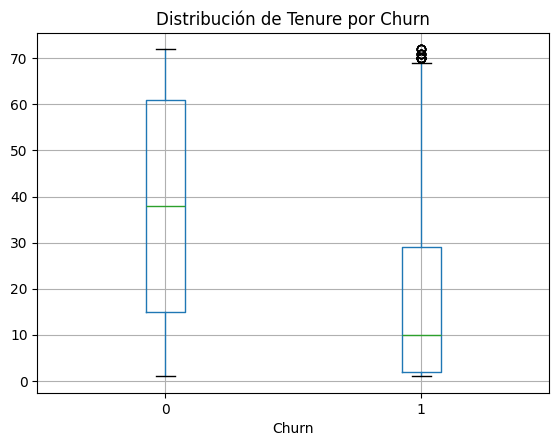

In [39]:
import matplotlib.pyplot as plt

df_final.boxplot(column="tenure", by="Churn")
plt.title("Distribución de Tenure por Churn")
plt.suptitle("")
plt.show()

<Axes: title={'center': 'Charges.Monthly'}, xlabel='Churn'>

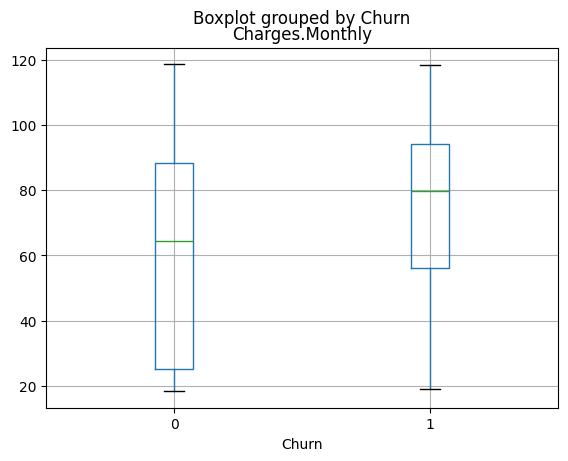

In [40]:
df_final.boxplot(column="Charges.Monthly", by="Churn")

In [41]:
df_final.groupby("Churn")["tenure"].mean().pct_change()

,tenure
Churn,
0,NaN
1,-0.522467


# **📄Informe final**

🔹 1. Introducción

El presente análisis tiene como objetivo principal comprender el fenómeno de evasión de clientes (Churn) en la empresa TelecomX.

La evasión representa uno de los principales desafíos estratégicos para empresas de servicios, ya que adquirir nuevos clientes suele ser significativamente más costoso que retener los existentes. Por ello, identificar los factores asociados a la cancelación del servicio permite diseñar estrategias preventivas basadas en datos.

A través de este estudio se busca:

Identificar patrones asociados a la cancelación.

Analizar diferencias entre clientes que permanecen y los que se retiran.

Detectar variables críticas que influyen en la evasión.

Proponer recomendaciones estratégicas basadas en evidencia.

🔹 2. Limpieza y Tratamiento de Datos

Durante esta etapa se realizaron los siguientes procesos:

📥 Importación

Carga del dataset original.

Revisión de estructura, tipos de datos y valores faltantes.

🧹 Limpieza

Conversión de variables numéricas que estaban en formato string (por ejemplo, Charges.Total).

Manejo de valores nulos y registros inconsistentes.

Eliminación o imputación según correspondiera.

🔄 Transformaciones

Codificación de la variable objetivo Churn (0 = No canceló, 1 = Canceló).

Estandarización de variables categóricas.

Creación de estructuras listas para análisis exploratorio.

Este proceso garantizó consistencia, calidad y confiabilidad en los resultados posteriores.

🔹 3. Análisis Exploratorio de Datos (EDA)

El análisis exploratorio permitió identificar patrones clave en la evasión.

📌 3.1 Distribución General de Churn

Se observó que una proporción relevante de clientes cancela el servicio, lo que confirma la importancia estratégica del problema.

📌 3.2 Variables Categóricas

Se analizaron variables como:

Género

Tipo de contrato

Método de pago

Servicios adicionales

Hallazgos importantes:

📄 Clientes con contratos mensuales presentan mayor tasa de cancelación.

💳 Métodos de pago automáticos muestran menor churn.

📦 Algunos servicios adicionales parecen influir en la permanencia.

Esto sugiere que la estabilidad contractual reduce la evasión.

📌 3.3 Variables Numéricas

Se compararon variables como:

tenure (tiempo de permanencia)

Charges.Monthly

Charges.Total

Hallazgos clave:

🔴 Clientes que cancelan:

Tienen menor tiempo de permanencia.

Presentan mayor cargo mensual promedio.

Han acumulado menor gasto total.

🟢 Clientes que permanecen:

Tienen mayor antigüedad.

Generan mayor ingreso total acumulado.

📊 Las visualizaciones (boxplots e histogramas) mostraron claramente que la evasión ocurre principalmente en las primeras etapas del ciclo de vida del cliente.

🔹 4. Conclusiones e Insights

A partir del análisis realizado, se identifican los siguientes insights estratégicos:

🎯 1. La evasión ocurre tempranamente

El churn se concentra en clientes con bajo tenure, lo que indica que el riesgo es mayor durante los primeros meses.

🎯 2. El precio mensual influye

Clientes con cargos mensuales más altos muestran mayor probabilidad de cancelación.

🎯 3. La estabilidad contractual reduce churn

Contratos de largo plazo están asociados con menor evasión.

🎯 4. El valor acumulado es clave

Clientes con mayor gasto histórico tienden a permanecer.

🔹 5. Recomendaciones Estratégicas

Basado en los hallazgos, se proponen las siguientes acciones:

🚀 1. Programa de Retención Temprana

Implementar estrategias de seguimiento durante los primeros 3–6 meses:

Ofertas personalizadas

Encuestas de satisfacción

Beneficios de fidelización temprana

💰 2. Revisión de Estrategia de Precios

Evaluar:

Segmentos con alto cargo mensual

Percepción de valor del servicio

Posibles planes escalonados o personalizados

📄 3. Incentivar Contratos de Largo Plazo

Ofrecer:

Descuentos por permanencia

Beneficios exclusivos por contrato anual

Bonificaciones por renovación

📊 4. Modelo Predictivo de Churn (Siguiente Paso)

Con los patrones identificados, se recomienda desarrollar un modelo de machine learning que permita:

Predecir probabilidad de cancelación.

Priorizar acciones de retención.

Optimizar recursos comerciales.

🏁 Conclusión Final

El análisis demuestra que la evasión no es aleatoria.
Existen patrones claros relacionados con:

Antigüedad del cliente

Tipo de contrato

Costo mensual

Valor acumulado

Estos hallazgos permiten transformar datos en decisiones estratégicas, reduciendo la tasa de churn y aumentando la rentabilidad del negocio.